In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [3]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

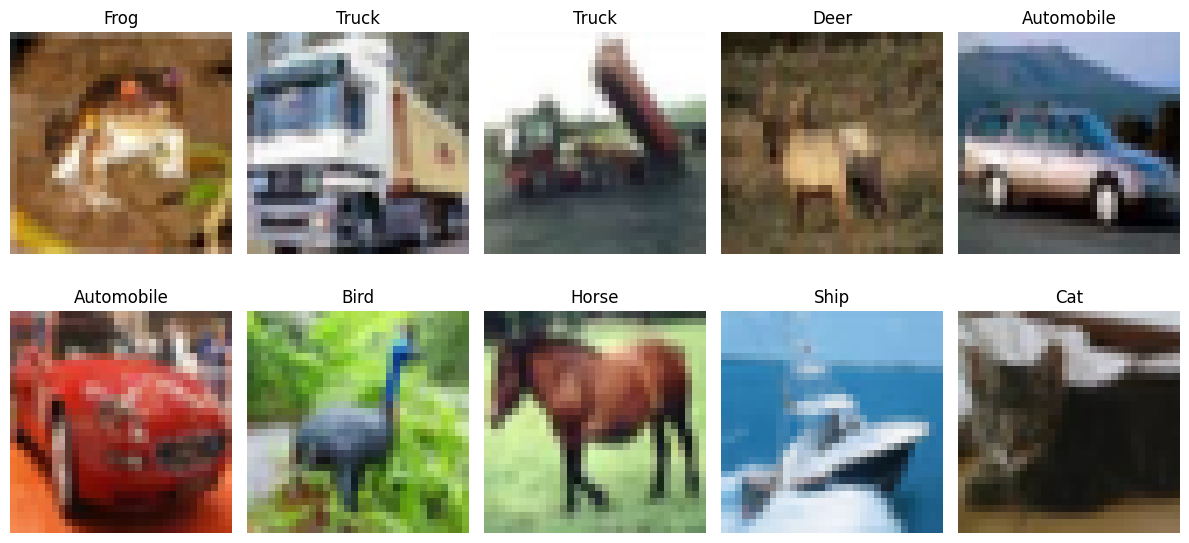

In [4]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [6]:
model = Sequential()

# Conv Block 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    )
)

model.add(MaxPooling2D((2,2)))

# Conv Block 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))

# Conv Block 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(256, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 92ms/step - accuracy: 0.4089 - loss: 1.6099 - val_accuracy: 0.5471 - val_loss: 1.2562
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - accuracy: 0.5653 - loss: 1.2172 - val_accuracy: 0.6241 - val_loss: 1.0549
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6338 - loss: 1.0398 - val_accuracy: 0.6697 - val_loss: 0.9409
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.6803 - loss: 0.9125 - val_accuracy: 0.7126 - val_loss: 0.8282
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7146 - loss: 0.8171 - val_accuracy: 0.7330 - val_loss: 0.7706
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7420 - loss: 0.7393 - val_accuracy: 0.7356 - val_loss: 0.7704
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7645 - loss: 0.6694 - val_accuracy: 0.7499 - val_loss: 0.7311
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7858 - loss: 0.6081 - 

In [9]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7545 - loss: 1.0233

Test Loss: 1.023278832435608
Test Accuracy: 0.7544999718666077


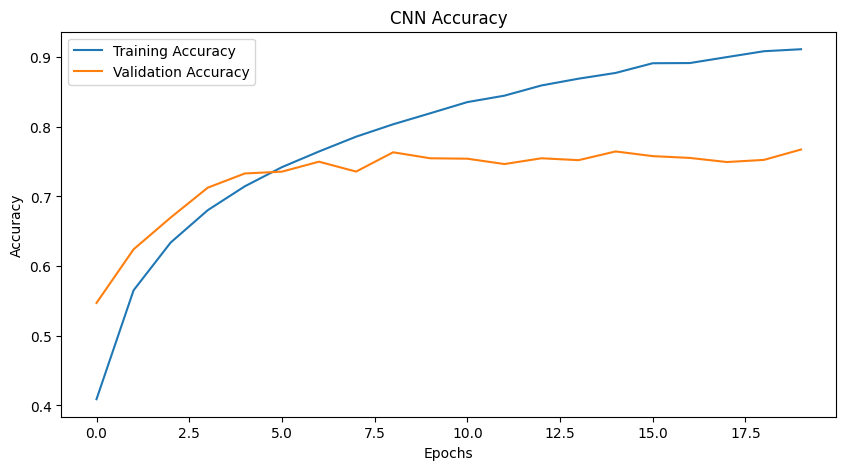

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

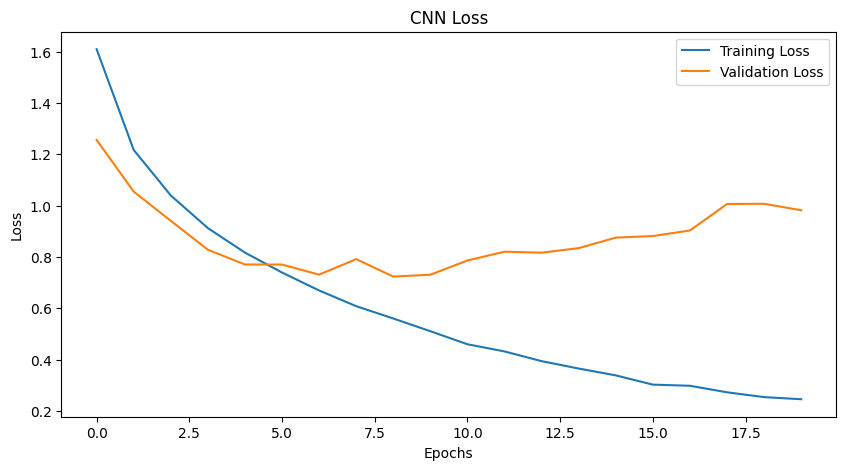

In [11]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


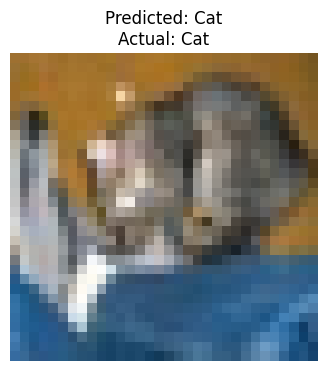

Confidence: 96.47226 %
Model saved successfully!


In [12]:
sample_index = 0

sample = X_test[sample_index]

prediction = model.predict(
    sample.reshape(1,32,32,3)
)

predicted_class = np.argmax(prediction)

actual_class = y_test[sample_index][0]

plt.figure(figsize=(4,4))
plt.imshow(sample)

plt.title(
    f"Predicted: {class_names[predicted_class]}\nActual: {class_names[actual_class]}"
)

plt.axis('off')
plt.show()

print("Confidence:", np.max(prediction)*100,"%")

# =====================================
# Save Model
# =====================================

model.save("cifar10_cnn_model.h5")

print("Model saved successfully!")

Saving download.webp to download.webp


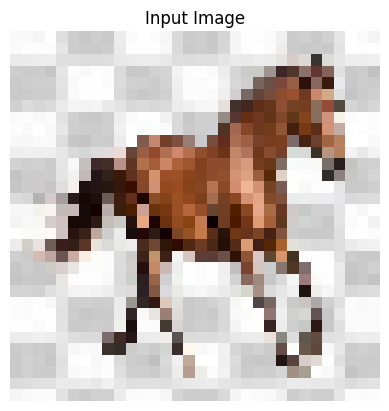

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Class: Horse
Confidence: 100.0 %


In [13]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (32,32))

plt.imshow(img)
plt.title("Input Image")
plt.axis('off')
plt.show()

img = img.astype('float32') / 255.0

img = img.reshape(1,32,32,3)

prediction = model.predict(img)

predicted_class = np.argmax(prediction)

print(
    "Predicted Class:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    np.max(prediction)*100,
    "%"
)